In [19]:
import csv
from focus_detect_alg import process_data
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# import and process dataset
src = Path("dataset")
results = process_data(src)

In [21]:
# load ground truth and evaluate predictions
ground_truth = {}
with open("ground_truth_files.csv", newline="") as f:
    for row in csv.DictReader(f):
        key = (row["folder"], row["quadrant"])
        ground_truth[key] = row["ground_truth_filename"]

correct = 0
total = 0
for folder, quadrants in results.items():
    for quadrant, variances in quadrants.items():
        pred_file, _ = max(variances, key=lambda item: item[1])
        true_file = ground_truth[(folder, quadrant)]
        correct += int(pred_file == true_file)
        total += 1

print(f"Overall: {correct}/{total} correct ({correct / total * 100:.1f}%)")

Overall: 36/40 correct (90.0%)


## 1. Overall correct vs. incorrect detections

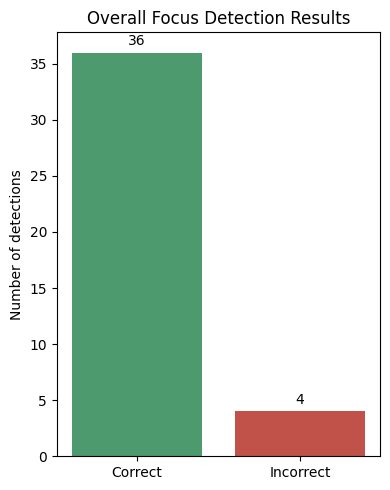

In [22]:
incorrect = total - correct

fig, ax = plt.subplots(figsize=(4, 5))
bars = ax.bar(["Correct", "Incorrect"], [correct, incorrect], color=["#4C9A6D", "#C0524A"])
ax.set_ylabel("Number of detections")
ax.set_title("Overall Focus Detection Results")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

## 2. Success rate by quadrant

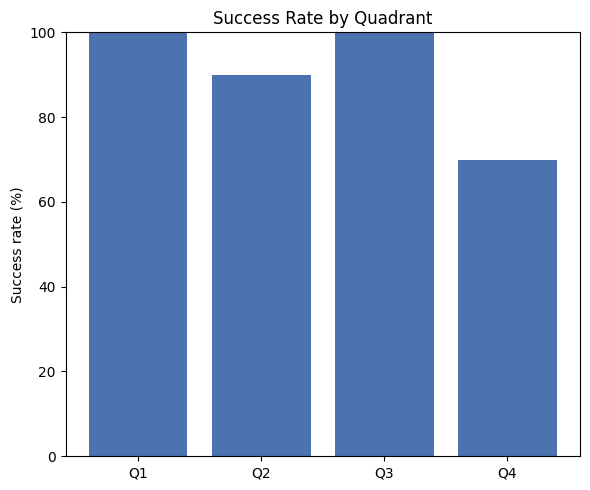

In [25]:
quadrant_order = ["Q1", "Q2", "Q3", "Q4"]
quad_correct = {q: 0 for q in quadrant_order}
quad_total = {q: 0 for q in quadrant_order}

for folder, quadrants in results.items():
    for quadrant, variances in quadrants.items():
        pred_file, _ = max(variances, key=lambda item: item[1])
        true_file = ground_truth[(folder, quadrant)]
        quad_total[quadrant] += 1
        quad_correct[quadrant] += int(pred_file == true_file)

quad_rates = [quad_correct[q] / quad_total[q] * 100 for q in quadrant_order]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(quadrant_order, quad_rates, color="#4C72B0")
ax.set_ylabel("Success rate (%)")
ax.set_ylim(0, 100)
ax.set_title("Success Rate by Quadrant")
plt.tight_layout()
plt.show()

## 3. Success rate by image set (folder)

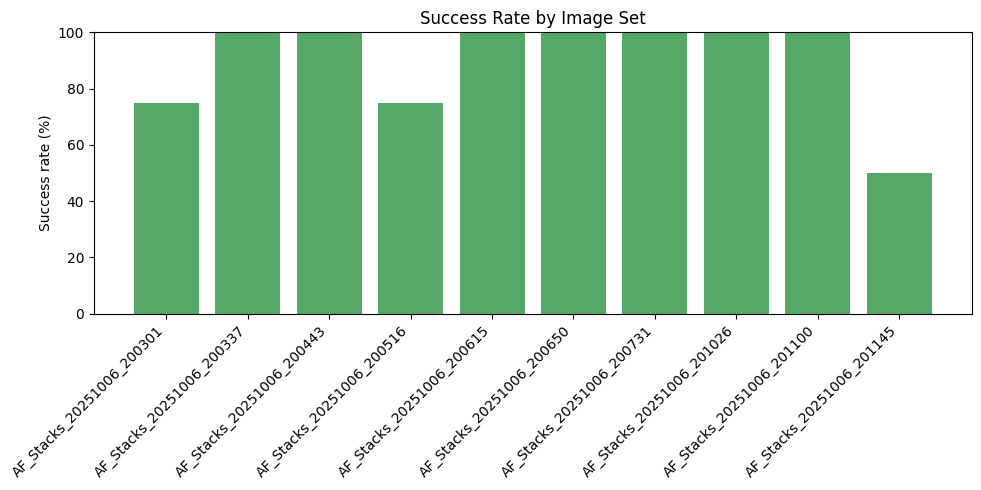

In [24]:
folder_order = sorted(results.keys())
folder_correct = {f: 0 for f in folder_order}
folder_total = {f: 0 for f in folder_order}

for folder, quadrants in results.items():
    for quadrant, variances in quadrants.items():
        pred_file, _ = max(variances, key=lambda item: item[1])
        true_file = ground_truth[(folder, quadrant)]
        folder_total[folder] += 1
        folder_correct[folder] += int(pred_file == true_file)

folder_rates = [folder_correct[f] / folder_total[f] * 100 for f in folder_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(folder_order)), folder_rates, color="#55A868")
ax.set_xticks(range(len(folder_order)))
ax.set_xticklabels(folder_order, rotation=45, ha="right")
ax.set_ylabel("Success rate (%)")
ax.set_ylim(0, 100)
ax.set_title("Success Rate by Image Set")
plt.tight_layout()
plt.show()